Import all the required libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer

Load the dataset

In [2]:
X, y = load_breast_cancer(return_X_y=True)

In [5]:
type(X)

numpy.ndarray

Split the data into train-test

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=44)

Model Training

Model 1: model_dt using DecisionTreeClassifier

In [7]:
model_dt = DecisionTreeClassifier()
model_dt.fit(X_train, y_train)

DecisionTreeClassifier()

Model Prediction

In [8]:
y_pred_dt = model_dt.predict(X_test)
print(y_pred_dt)

[0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 1 1 0 1 0 0 1 0 0 1 0 0 1 0
 0 0 0]


Model Evaluation using Decision Tree

In [9]:
print('accuracy score: ', accuracy_score(y_test, y_pred_dt))
print('recall score: ', recall_score(y_test, y_pred_dt))

accuracy score:  0.9385964912280702
recall score:  0.9466666666666667


Model 2: model_bag using BaggingClassifier

In [10]:
from sklearn.svm import SVC

# model_bag = BaggingClassifier(estimator = SVC(), n_estimators=100, random_state=44)
model_bag = BaggingClassifier(estimator = DecisionTreeClassifier(), n_estimators=100, random_state=44)
model_bag.fit(X_train, y_train)

BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100,
                  random_state=44)

In [11]:
y_pred_bag = model_bag.predict(X_test)
print(y_pred_bag)

[0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 0 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0
 0 0 0]


Model Evaluation using BaggingClassifier

In [12]:
print('accuracy score: ', accuracy_score(y_test, y_pred_bag))
print('recall score: ', recall_score(y_test, y_pred_bag))

accuracy score:  0.9736842105263158
recall score:  0.9733333333333334


Model 3: model_rf using RandomForestClassifier

In [13]:
model_rf = RandomForestClassifier()
model_rf.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
y_pred_rf = model_rf.predict(X_test)
print(y_pred_rf)

[0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0
 0 0 0]


Model Evaluation using RandomForestClassifier

In [15]:
print('accuracy score: ', accuracy_score(y_test, y_pred_rf))
print('recall score: ', recall_score(y_test, y_pred_rf))

accuracy score:  0.9649122807017544
recall score:  0.9733333333333334


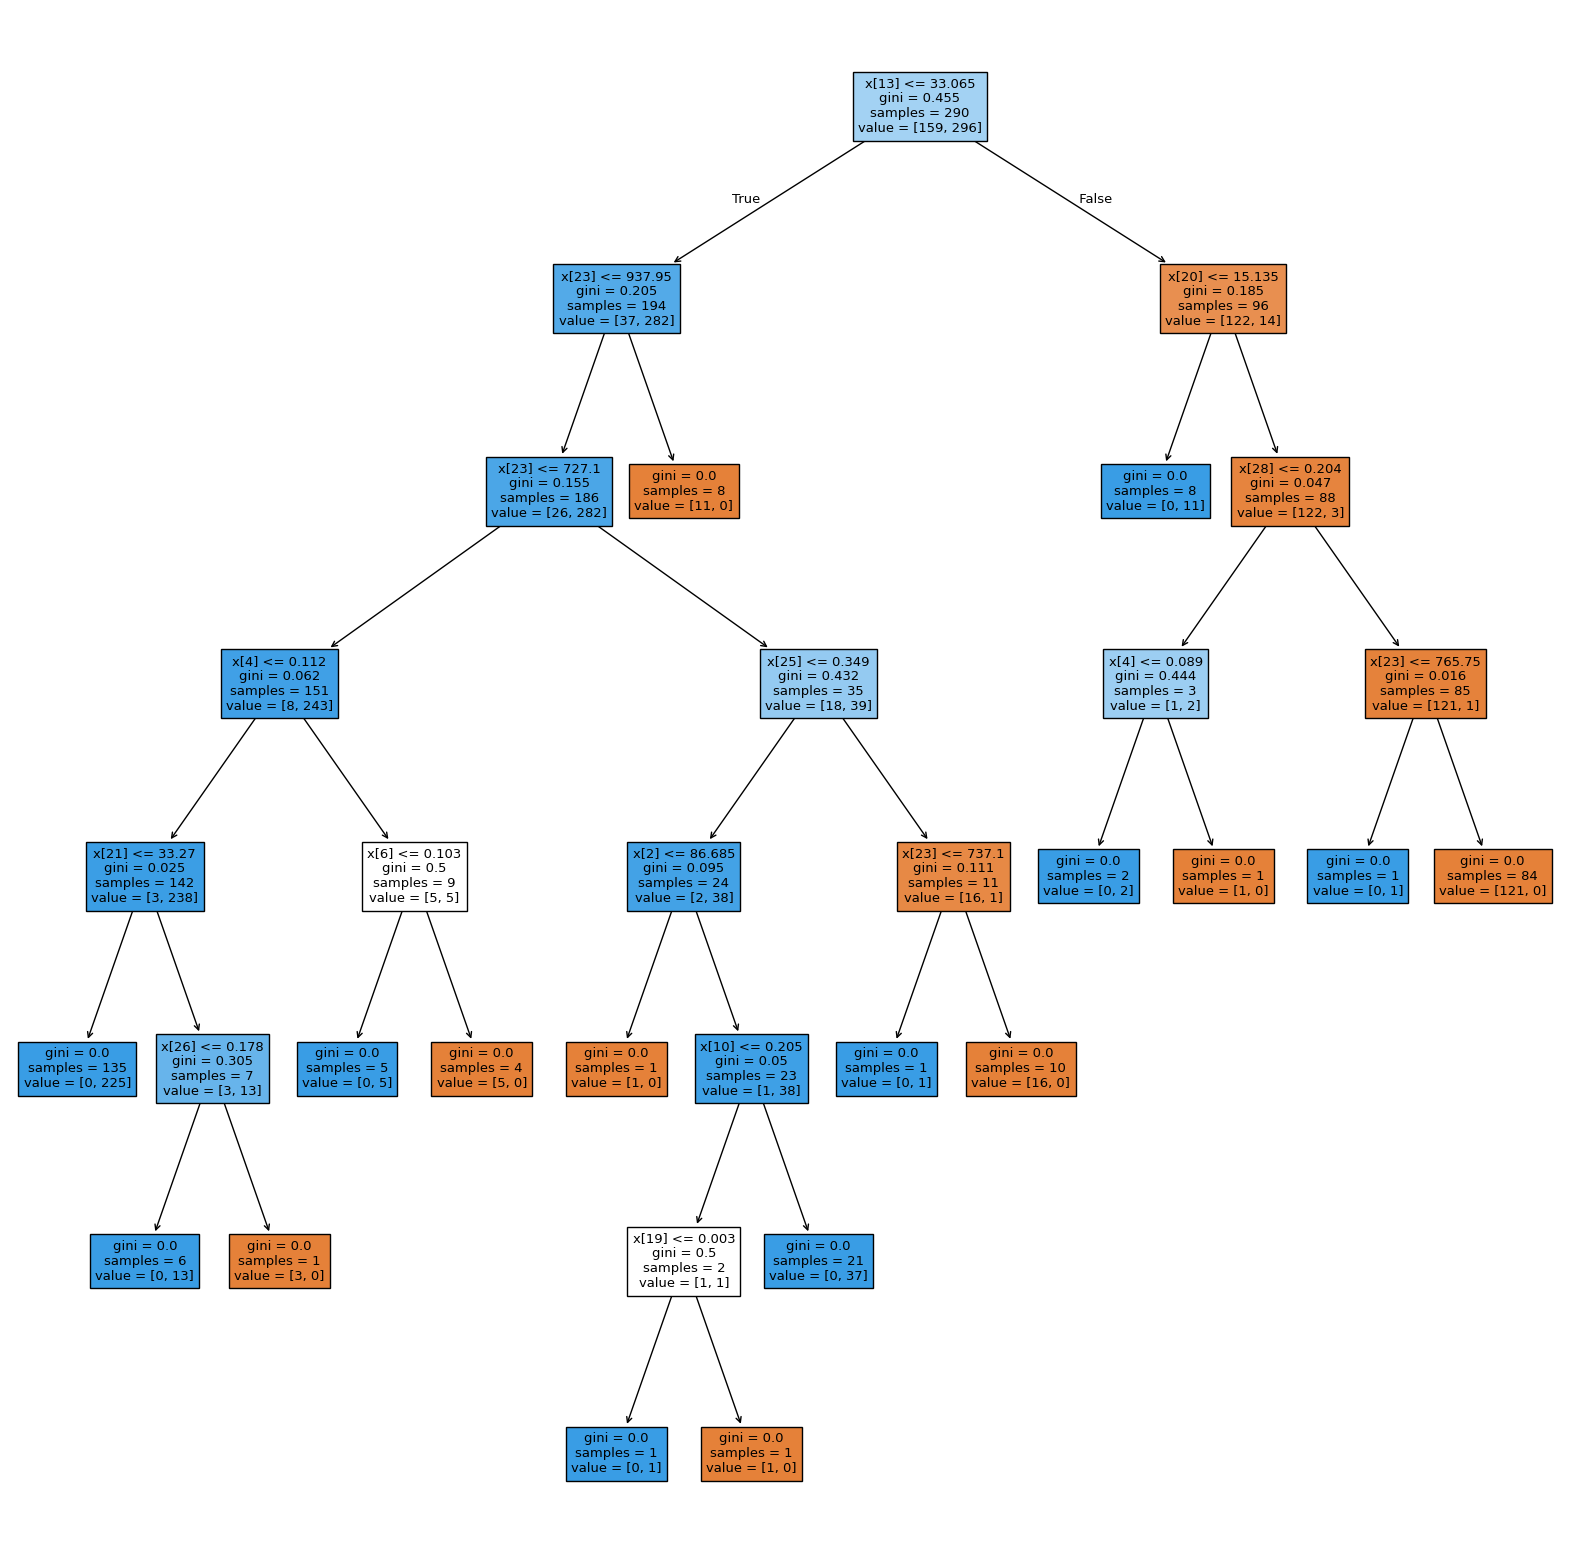

In [18]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20, 20))
plot_tree(model_rf.estimators_[66], filled=True)
plt.savefig('dt1.png')
plt.show()

Hyperparameter Tuning

Optimization of the model: GridSearchCV

In [19]:
grid_parameters = {
    'n_estimators': [50, 80, 100, 120],
    'criterion': ['gini', 'entropy'],
    'max_depth': range(8)
}

In [21]:
from sklearn.model_selection import GridSearchCV
grid_search_rf = GridSearchCV(param_grid=grid_parameters, estimator=model_rf)
grid_search_rf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
40 fits failed out of a total of 320.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
40 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/

GridSearchCV(estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': range(0, 8),
                         'n_estimators': [50, 80, 100, 120]})

In [22]:
grid_search_rf.best_params_

{'criterion': 'gini', 'max_depth': 7, 'n_estimators': 50}

In [23]:
model_rf_v2 = RandomForestClassifier(n_estimators=50, max_depth=7)
model_rf_v2.fit(X_train, y_train)

RandomForestClassifier(max_depth=7, n_estimators=50)

In [24]:
y_pred_rf_v2 = model_rf_v2.predict(X_test)
print(y_pred_rf_v2)

[0 0 1 0 1 1 1 0 0 1 1 1 0 0 1 1 1 0 0 1 1 1 1 1 1 0 1 1 0 1 1 1 1 1 1 1 1
 1 1 1 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 0 1 1 1 1 1 1 1 0 1 0 0 1 0 0 0 1 0 1
 1 0 0 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 1 1 1 0 1 1 0 1 0 0 1 0 1 0 0 0 1 0
 0 0 0]


In [25]:
print('accuracy score: ', accuracy_score(y_test, y_pred_rf_v2))
print('recall score: ', recall_score(y_test, y_pred_rf_v2))

accuracy score:  0.9649122807017544
recall score:  0.9733333333333334


Limitation of Bagging models

1. High computational cost

2. Less Interpretation

Model Explainability by evaluating the feature importance

In [26]:
model_rf_v2.feature_importances_

array([0.03977957, 0.01116283, 0.07449585, 0.06342973, 0.00659305,
       0.02086144, 0.05975142, 0.08880226, 0.0027582 , 0.00330653,
       0.0055269 , 0.00591047, 0.00583728, 0.01151725, 0.00470417,
       0.00388167, 0.00313382, 0.00237345, 0.00252356, 0.00508835,
       0.09964431, 0.01735196, 0.16537867, 0.15689589, 0.02406992,
       0.01465057, 0.02837915, 0.05262267, 0.01522297, 0.00434611])